DARK STORE OPERATIONS SIMULATOR

Executive Insights & Scenario Analysis

Objective:

- Convert analysis into business decisions
- Prioritize operational issues
- Estimate impact of improvements
- Build executive recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/orders.csv")
inventory = pd.read_csv("../data/inventory.csv")

In [2]:
executive_kpi = pd.DataFrame({

    "Metric":[
        "Orders",
        "Revenue",
        "Avg Order Value",
        "SLA Breach %",
        "Stockout %",
        "Cancellation %",
        "Rating"
    ],

    "Value":[

        len(orders),

        round(orders["revenue_inr"].sum(),2),

        round(orders["revenue_inr"].mean(),2),

        round(orders["sla_breached"].mean()*100,2),

        round(orders["stockout_flag"].mean()*100,2),

        round(orders["cancelled_flag"].mean()*100,2),

        round(orders["customer_rating"].mean(),2)

    ]
})

executive_kpi

,Metric,Value
0,Orders,25000.00
1,Revenue,24162205.20
2,Avg Order Value,966.49
3,SLA Breach %,62.81
4,Stockout %,15.17
5,Cancellation %,6.08
6,Rating,3.89


In [3]:
lost_revenue = orders[
    (orders["stockout_flag"]==1) &
    (orders["cancelled_flag"]==1)
]["revenue_inr"].sum()

print("Revenue Lost Due To Stockouts:")
print(round(lost_revenue,2))

Revenue Lost Due To Stockouts:
1469770.57


In [4]:
lost_pct = (

    lost_revenue /

    orders["revenue_inr"].sum()

)*100

print(round(lost_pct,2),"%")

6.08 %


In [5]:
risk = orders.groupby("store_id").agg({

    "sla_breached":"mean",

    "stockout_flag":"mean",

    "cancelled_flag":"mean"

})

risk["risk_score"] = (

    risk["sla_breached"]*50 +

    risk["stockout_flag"]*30 +

    risk["cancelled_flag"]*20

)

risk.sort_values(
    "risk_score",
    ascending=False
).head(3)

,sla_breached,stockout_flag,cancelled_flag,risk_score
store_id,,,,
DS_Pune_Kothrud,0.630897,0.158187,0.066297,37.616405
DS_Mumbai_Andheri,0.634319,0.154563,0.062661,37.606041
DS_Mumbai_BKC,0.630000,0.151935,0.065161,37.361290


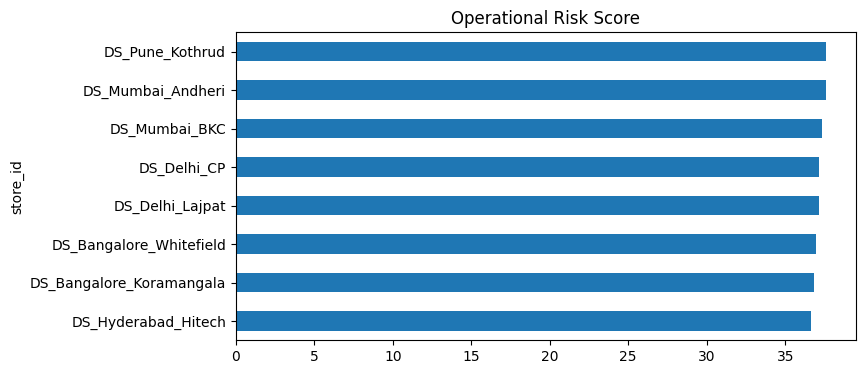

In [6]:
risk["risk_score"] \
.sort_values() \
.plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Operational Risk Score")

plt.show()

In [14]:
current_breach = round(
    orders["sla_breached"].mean()*100,
    2
)

peak_breach = round(

    orders[
        orders["is_peak_hour"]==1
    ]["sla_breached"].mean()*100,

    2
)

offpeak_breach = round(

    orders[
        orders["is_peak_hour"]==0
    ]["sla_breached"].mean()*100,

    2
)

print(
    "Overall SLA Breach:",
    current_breach,
    "%"
)

print(
    "Peak Hour SLA Breach:",
    peak_breach,
    "%"
)

print(
    "Off Peak SLA Breach:",
    offpeak_breach,
    "%"
)

Overall SLA Breach: 62.81 %
Peak Hour SLA Breach: 95.18 %
Off Peak SLA Breach: 42.36 %


In [21]:
category_stockout = orders.groupby(
    "category"
)["stockout_flag"] \
.mean() \
.mul(100) \
.round(2) \
.sort_values(
    ascending=False
)

category_stockout

category
Personal Care    15.67
Fruits & Veg     15.37
Frozen           15.36
Staples          15.14
Snacks           15.08
Dairy            15.07
Beverages        14.48
Name: stockout_flag, dtype: float64

In [27]:
lost_revenue_by_category = orders[

    (orders["stockout_flag"]==1) &
    (orders["cancelled_flag"]==1)

].groupby(

    "category"

)["revenue_inr"] \
.sum() \
.sort_values(
    ascending=False
)

lost_revenue_by_category

category
Personal Care    238348.91
Snacks           223985.16
Staples          220678.06
Dairy            211978.23
Fruits & Veg     196077.77
Beverages        194675.41
Frozen           184027.03
Name: revenue_inr, dtype: float64

In [32]:
orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

daily_orders = orders.groupby(

    orders["order_timestamp"].dt.date

)["order_id"] \
.count()

daily_orders.describe()

count    365.000000
mean      68.493151
std        8.127628
min       47.000000
25%       63.000000
50%       68.000000
75%       73.000000
max       95.000000
Name: order_id, dtype: float64

In [36]:
avg_daily_orders = round(
    daily_orders.mean(),
    0
)

future_orders = round(
    avg_daily_orders * 1.20,
    0
)

print(
    "Current Daily Orders:",
    avg_daily_orders
)

print(
    "Projected Daily Orders (+20%):",
    future_orders
)

Current Daily Orders: 68.0
Projected Daily Orders (+20%): 82.0


In [39]:
sla_pct = round(
    orders["sla_breached"].mean()*100,
    1
)

stockout_pct = round(
    orders["stockout_flag"].mean()*100,
    1
)

cancel_pct = round(
    orders["cancelled_flag"].mean()*100,
    1
)

print("Executive Recommendations")

print("-"*40)

if sla_pct > 20:
    print(
        "1. Increase staffing during peak hours"
    )

if stockout_pct > 10:
    print(
        "2. Improve inventory replenishment"
    )

if cancel_pct > 5:
    print(
        "3. Reduce stockout-driven cancellations"
    )

print(
    "4. Monitor high-risk stores weekly"
)

Executive Recommendations
----------------------------------------
1. Increase staffing during peak hours
2. Improve inventory replenishment
3. Reduce stockout-driven cancellations
4. Monitor high-risk stores weekly


In [40]:
top_store = risk[
    "risk_score"
].idxmax()

print(f"""

EXECUTIVE SUMMARY

1. Total Orders:
   {len(orders):,}

2. Total Revenue:
   ₹{orders['revenue_inr'].sum():,.0f}

3. Revenue Lost:
   ₹{lost_revenue:,.0f}

4. Highest Risk Store:
   {top_store}

5. Key Operational Risks:
   - SLA Breaches
   - Inventory Stockouts
   - Order Cancellations

6. Recommended Focus:
   - Peak-hour staffing
   - Inventory planning
   - Store-level monitoring

""")



EXECUTIVE SUMMARY

1. Total Orders:
   25,000

2. Total Revenue:
   ₹24,162,205

3. Revenue Lost:
   ₹1,469,771

4. Highest Risk Store:
   DS_Pune_Kothrud

5. Key Operational Risks:
   - SLA Breaches
   - Inventory Stockouts
   - Order Cancellations

6. Recommended Focus:
   - Peak-hour staffing
   - Inventory planning
   - Store-level monitoring


